# Neo4j Graph RAG — Latency Test

This notebook measures the latency of querying the Neo4j knowledge graph built in `testingGraphRag.ipynb`.  
It breaks down timing into:
- **Neo4j retrieval** (Cypher query)
- **LLM generation** (Ollama)
- **Total end-to-end**

In [1]:
import time
import json
import statistics
from neo4j import GraphDatabase
import ollama
import pandas as pd

## Configuration

In [2]:
LLM_MODEL = "llama3:8b"

NEO4J_URI = "bolt://localhost:7687"
NEO4J_USER = "neo4j"
NEO4J_PASSWORD = "testpassword"

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
driver.verify_connectivity()
print("Connected to Neo4j!")

Connected to Neo4j!


## Define Query Function with Latency Breakdown

In [3]:
def graph_rag_query_timed(question, driver, model=LLM_MODEL, top_k=20):
    """
    Query the Neo4j graph and generate an answer via Ollama.
    Returns (answer, timings_dict) where timings_dict has:
      - retrieval_ms: time for Neo4j Cypher query
      - generation_ms: time for Ollama LLM call
      - total_ms: end-to-end time
      - context_lines: number of context lines retrieved
    """
    t_start = time.perf_counter()

    # ── Neo4j Retrieval ──
    t_ret_start = time.perf_counter()
    with driver.session() as session:
        keywords = [w for w in question.split() if len(w) > 3]
        where_clause = " OR ".join(
            [f"toLower(n.name) CONTAINS toLower($kw{i}) OR toLower(n.description) CONTAINS toLower($kw{i})"
             for i in range(len(keywords))]
        )
        params = {f"kw{i}": kw for i, kw in enumerate(keywords)}
        if not where_clause:
            where_clause = "TRUE"

        cypher = (
            f"MATCH (n:Entity) WHERE {where_clause} "
            "WITH n LIMIT $top_k "
            "OPTIONAL MATCH (n)-[r]-(m:Entity) "
            "RETURN n.name AS entity, n.type AS type, n.description AS desc, "
            "       r.relation AS rel, m.name AS connected_to "
            "LIMIT 200"
        )
        params["top_k"] = top_k
        result = session.run(cypher, **params)

        context_lines = []
        for record in result:
            line = f"Entity: {record['entity']} (type: {record['type']})"
            if record["desc"]:
                line += f" — {record['desc']}"
            if record["connected_to"]:
                line += f" | Relation: {record['rel']} → {record['connected_to']}"
            context_lines.append(line)
    t_ret_end = time.perf_counter()

    context_str = "\n".join(context_lines) if context_lines else "No relevant entities found."

    # ── LLM Generation ──
    t_gen_start = time.perf_counter()
    prompt = (
        f"Based on the following knowledge graph context, answer the question.\n\n"
        f"CONTEXT:\n{context_str}\n\n"
        f"QUESTION: {question}\n\n"
        f"Provide a detailed, well-structured answer based only on the context above."
    )
    response = ollama.chat(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        options={"temperature": 0.3},
    )
    answer = response["message"]["content"]
    t_gen_end = time.perf_counter()

    t_end = time.perf_counter()

    timings = {
        "retrieval_ms": (t_ret_end - t_ret_start) * 1000,
        "generation_ms": (t_gen_end - t_gen_start) * 1000,
        "total_ms": (t_end - t_start) * 1000,
        "context_lines": len(context_lines),
    }
    return answer, timings

print("Timed query function defined.")

Timed query function defined.


## Test Questions

Define a set of questions to benchmark against the knowledge graph.

In [4]:
TEST_QUESTIONS = [
    "What are the main techniques used in Large Language Models?",
    "What is the Transformer architecture?",
    "How does Reinforcement Learning from Human Feedback work?",
    "What are the key differences between GPT-3 and GPT-4?",
    "What is prompt engineering?",
    "What datasets are used for evaluating language models?",
    "What is the role of attention mechanisms in NLP?",
    "How do pre-trained language models improve downstream tasks?",
    "What are Statistical Language Models?",
    "What is the evolution of language models over time?",
]

print(f"{len(TEST_QUESTIONS)} test questions ready.")

10 test questions ready.


## Run Latency Benchmark

In [5]:
results = []

for idx, question in enumerate(TEST_QUESTIONS):
    answer, timings = graph_rag_query_timed(question, driver)
    results.append({
        "question": question,
        "answer_preview": answer[:120] + "..." if len(answer) > 120 else answer,
        **timings,
    })
    print(f"[{idx+1}/{len(TEST_QUESTIONS)}] "
          f"Retrieval: {timings['retrieval_ms']:.1f}ms | "
          f"Generation: {timings['generation_ms']:.1f}ms | "
          f"Total: {timings['total_ms']:.1f}ms | "
          f"Context: {timings['context_lines']} lines")

print("\nBenchmark complete!")

[1/10] Retrieval: 6.8ms | Generation: 2199.4ms | Total: 2206.2ms | Context: 92 lines
[2/10] Retrieval: 70.5ms | Generation: 2291.6ms | Total: 2362.2ms | Context: 13 lines
[3/10] Retrieval: 79.8ms | Generation: 1487.6ms | Total: 1567.4ms | Context: 24 lines
[4/10] Retrieval: 65.6ms | Generation: 3372.8ms | Total: 3438.4ms | Context: 14 lines
[5/10] Retrieval: 49.7ms | Generation: 1560.9ms | Total: 1610.6ms | Context: 6 lines
[6/10] Retrieval: 68.6ms | Generation: 3855.5ms | Total: 3924.1ms | Context: 92 lines
[7/10] Retrieval: 57.0ms | Generation: 1919.2ms | Total: 1976.2ms | Context: 5 lines
[8/10] Retrieval: 65.2ms | Generation: 3407.7ms | Total: 3472.9ms | Context: 92 lines
[9/10] Retrieval: 52.6ms | Generation: 3097.3ms | Total: 3149.9ms | Context: 97 lines
[10/10] Retrieval: 6.0ms | Generation: 4516.9ms | Total: 4522.9ms | Context: 92 lines

Benchmark complete!


## Results Summary

In [6]:
df = pd.DataFrame(results)

print("=" * 70)
print("LATENCY SUMMARY")
print("=" * 70)

for col in ["retrieval_ms", "generation_ms", "total_ms"]:
    vals = df[col]
    label = col.replace("_ms", "").capitalize()
    print(f"\n{label}:")
    print(f"  Mean:   {vals.mean():.1f} ms")
    print(f"  Median: {vals.median():.1f} ms")
    print(f"  Min:    {vals.min():.1f} ms")
    print(f"  Max:    {vals.max():.1f} ms")
    print(f"  Std:    {vals.std():.1f} ms")

print(f"\nAvg context lines retrieved: {df['context_lines'].mean():.1f}")
print(f"Retrieval % of total: {(df['retrieval_ms'].sum() / df['total_ms'].sum() * 100):.1f}%")
print(f"Generation % of total: {(df['generation_ms'].sum() / df['total_ms'].sum() * 100):.1f}%")

LATENCY SUMMARY

Retrieval:
  Mean:   52.2 ms
  Median: 61.1 ms
  Min:    6.0 ms
  Max:    79.8 ms
  Std:    25.7 ms

Generation:
  Mean:   2770.9 ms
  Median: 2694.5 ms
  Min:    1487.6 ms
  Max:    4516.9 ms
  Std:    1027.0 ms

Total:
  Mean:   2823.1 ms
  Median: 2756.0 ms
  Min:    1567.4 ms
  Max:    4522.9 ms
  Std:    1020.1 ms

Avg context lines retrieved: 52.7
Retrieval % of total: 1.8%
Generation % of total: 98.2%


## Results Table

In [7]:
display_df = df[["question", "retrieval_ms", "generation_ms", "total_ms", "context_lines"]].copy()
display_df.columns = ["Question", "Retrieval (ms)", "Generation (ms)", "Total (ms)", "Context Lines"]
for col in ["Retrieval (ms)", "Generation (ms)", "Total (ms)"]:
    display_df[col] = display_df[col].round(1)
display_df

,Question,Retrieval (ms),Generation (ms),Total (ms),Context Lines
0,What are the main techniques used in Large Lan...,6.8,2199.4,2206.2,92
1,What is the Transformer architecture?,70.5,2291.6,2362.2,13
2,How does Reinforcement Learning from Human Fee...,79.8,1487.6,1567.4,24
3,What are the key differences between GPT-3 and...,65.6,3372.8,3438.4,14
4,What is prompt engineering?,49.7,1560.9,1610.6,6
5,What datasets are used for evaluating language...,68.6,3855.5,3924.1,92
6,What is the role of attention mechanisms in NLP?,57.0,1919.2,1976.2,5
7,How do pre-trained language models improve dow...,65.2,3407.7,3472.9,92
8,What are Statistical Language Models?,52.6,3097.3,3149.9,97
9,What is the evolution of language models over ...,6.0,4516.9,4522.9,92


## Latency Visualization

/tmp/ipykernel_4136748/2979345724.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([df["retrieval_ms"], df["generation_ms"], df["total_ms"]],


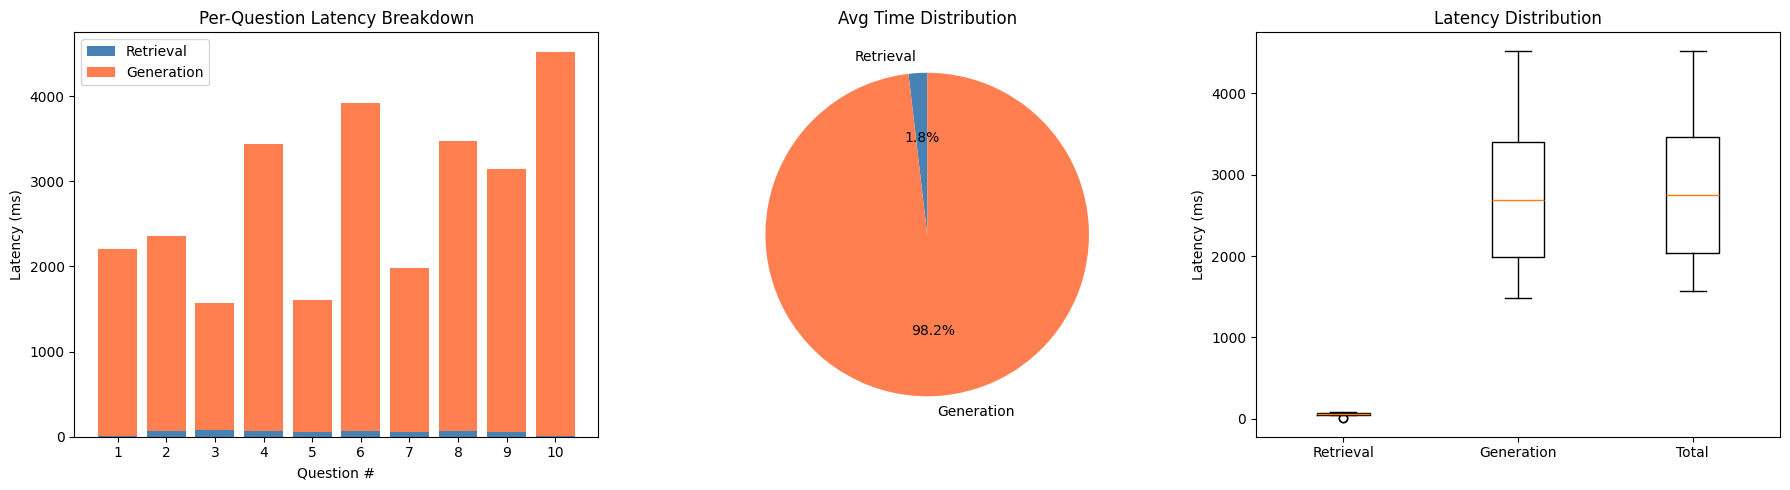

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart: per-question breakdown
x = range(len(df))
axes[0].bar(x, df["retrieval_ms"], label="Retrieval", color="steelblue")
axes[0].bar(x, df["generation_ms"], bottom=df["retrieval_ms"], label="Generation", color="coral")
axes[0].set_xlabel("Question #")
axes[0].set_ylabel("Latency (ms)")
axes[0].set_title("Per-Question Latency Breakdown")
axes[0].set_xticks(x)
axes[0].set_xticklabels([str(i+1) for i in x])
axes[0].legend()

# Pie chart: average time split
avg_ret = df["retrieval_ms"].mean()
avg_gen = df["generation_ms"].mean()
axes[1].pie([avg_ret, avg_gen], labels=["Retrieval", "Generation"],
            autopct="%1.1f%%", colors=["steelblue", "coral"], startangle=90)
axes[1].set_title("Avg Time Distribution")

# Box plot: total latency distribution
axes[2].boxplot([df["retrieval_ms"], df["generation_ms"], df["total_ms"]],
                labels=["Retrieval", "Generation", "Total"])
axes[2].set_ylabel("Latency (ms)")
axes[2].set_title("Latency Distribution")

plt.tight_layout()
plt.show()

## Export Results

In [ ]:
output_file = "latency_results.csv"
df.to_csv(output_file, index=False)
print(f"Results saved to {output_file}")

## Cleanup

In [ ]:
driver.close()
print("Neo4j driver closed.")